In [1]:
import hoda
import tensorly as tl
import mne

mne.set_log_level('ERROR')
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300, MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler

paradigm = P300(resample=64)
dataset = BNCI2015_003()


epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[2],
                                         return_epochs=True)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]



To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
meta

,subject,session,run
0,2,0,0train
1,2,0,0train
2,2,0,0train
3,2,0,0train
4,2,0,0train
...,...,...,...
5395,2,0,1test
5396,2,0,1test
5397,2,0,1test
5398,2,0,1test


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
import numpy as np
from sklearn.model_selection import train_test_split


X = epochs.get_data()
X = tl.tensor(X)
y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42)

print(X.shape)
print(X.dtype)
print(X.device)

(5400, 8, 52)
float32
<CUDA Device 0>


In [30]:
from hoda.hoda import BTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter


bttda = BTTDA(
    ranks=[1]*64,
    hoda_params=dict(
        max_iter=256,
        tol=1e-12,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=True,
        extra_train_info=False,
        verbose=True,
        forward=False,
        random_state=42,
       
    ),
    verbose=True,
    extra_train_info=True,
)
#%env PYTHONWARNINGS=ignore
%time bttda.fit(X_train,y_train, X_test=X_test, y_test=y_test)

Fitting block 1/64...


  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

Fitting block 2/64...


  0%|          | 0/256 [00:00<?, ?it/s]

...

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

Fitting block 4/64...


  0%|          | 0/256 [00:00<?, ?it/s]


KeyboardInterrupt



In [27]:
import pandas as pd
df = pd.DataFrame(bttda.train_info_)
df

,block,rank,mse,nmse,F_tr,F_rt,split
0,1,"(1, 1)",7.809343e-11,0.990574,0.984016,0.000729,test
1,1,"(1, 1)",7.731623e-11,0.990687,1.465870,0.001086,train
2,2,"(1, 1)",7.688861e-11,0.975291,0.906911,0.000817,test
3,2,"(1, 1)",7.600380e-11,0.973870,1.394067,0.001493,train
4,3,"(1, 1)",7.659261e-11,0.971537,0.774232,0.000824,test
...,...,...,...,...,...,...,...
123,62,"(1, 1)",6.695176e-11,0.857883,0.617734,0.002296,train
124,63,"(1, 1)",6.815064e-11,0.864455,0.351976,0.000989,test
125,63,"(1, 1)",6.689200e-11,0.857117,0.617300,0.002297,train
126,64,"(1, 1)",6.811169e-11,0.863961,0.351353,0.000990,test


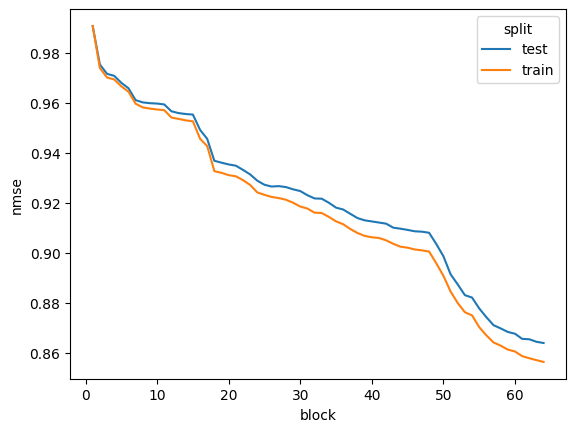

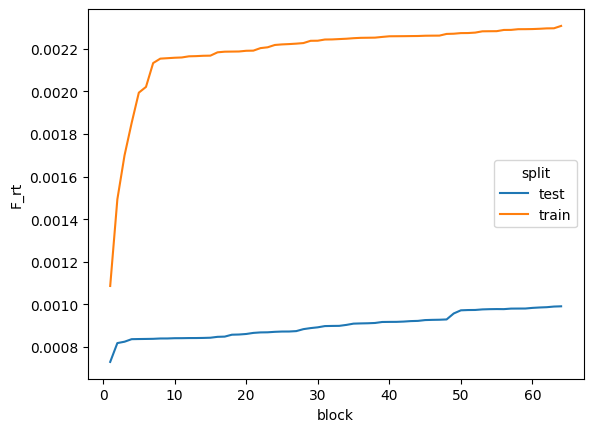

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')
if bttda.extra_train_info:
    n_samples = X.shape[0]
    sns.lineplot(data=df, x='block', y='nmse', hue='split')
    plt.show()
    #sns.lineplot(data=df,x='block',y='F_rt', hue='split')
    #plt.show()
    sns.lineplot(data=df,x='block',y='F_rt', hue='split')

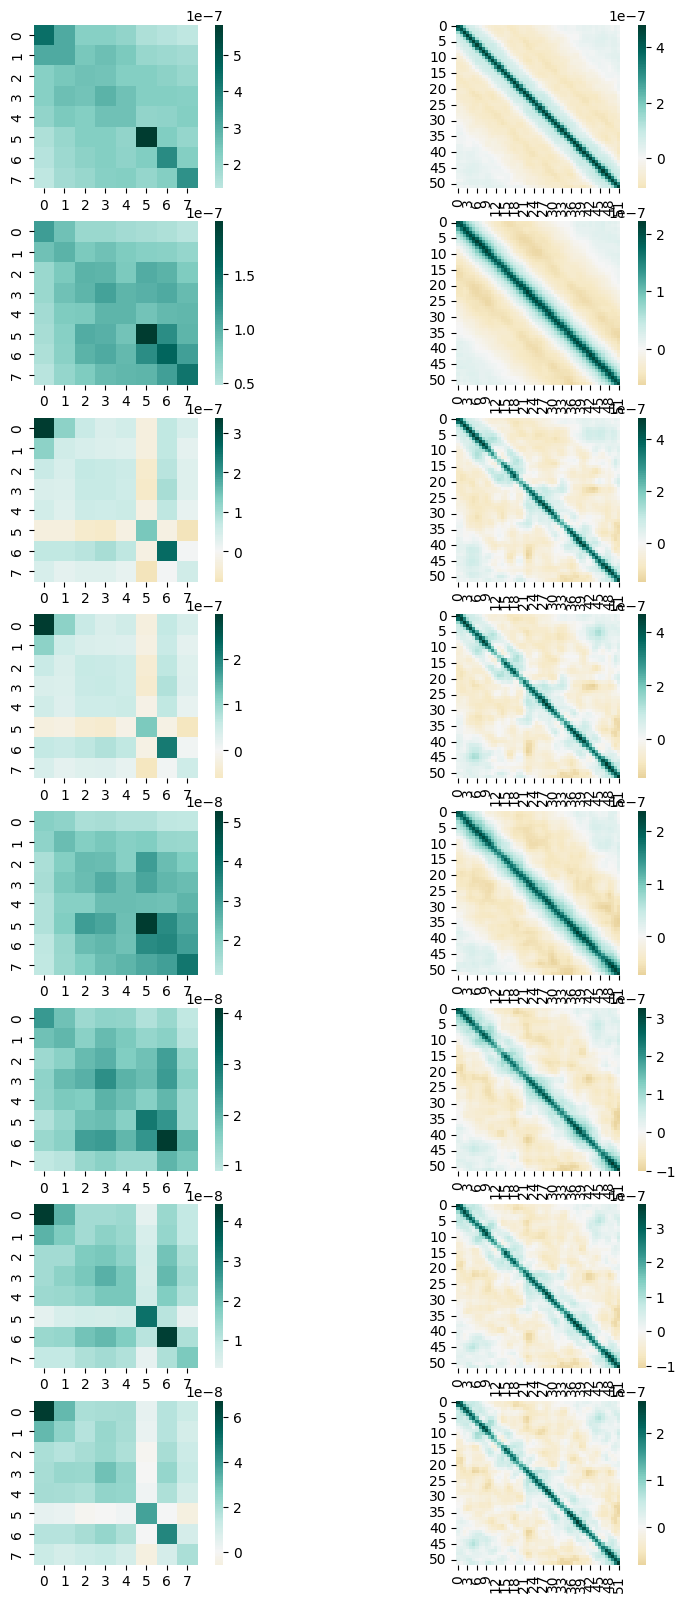

In [17]:
fig, axs = plt.subplots(min(bttda.n_blocks_,8),2, figsize=(10,20))
for b in range(min(bttda.n_blocks_,8)):
    for k in range(2):
        scatter = bttda.blocks_[b].scatter_w_[k]
        scatter = tl.to_numpy(scatter)
        sns.heatmap(scatter, ax=axs[b,k], square=True, center=0, cmap='BrBG')

In [18]:
Xt = tl.to_numpy(bttda.transform(X))

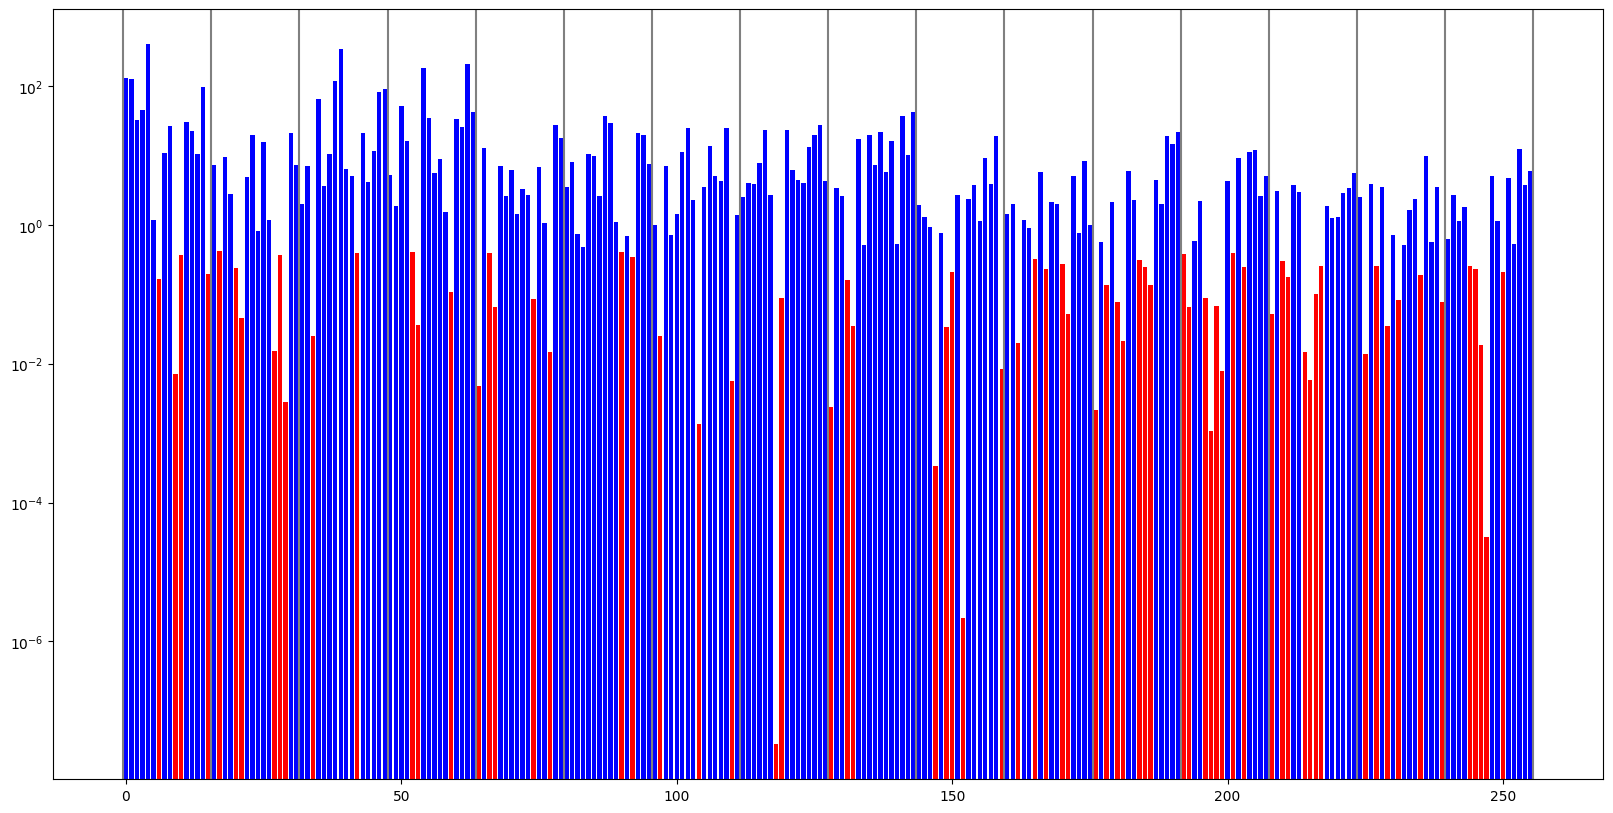

In [19]:
import scipy.stats
import seaborn as sns
import math
import numpy as np

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)

alpha=0.5
sig_idc = p < alpha

fig, ax = plt.subplots(1,1, figsize=(20,10))
ax.bar(np.arange(len(F))[sig_idc],F[sig_idc], color='blue')
ax.bar(np.arange(len(F))[~sig_idc],F[~sig_idc], color='red')
ax.set_yscale('log')
n_params=0
ax.axvline(n_params-.5, color='grey')
for b in bttda.blocks_:
    n_params+=math.prod(b.rank_)
    ax.axvline(n_params-.5, color='grey')


<Axes: >

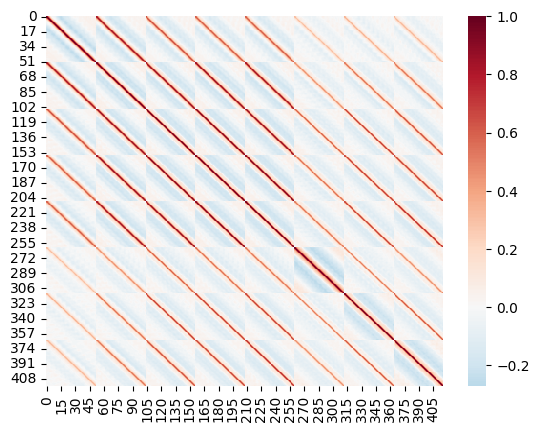

In [20]:
sns.heatmap(np.corrcoef(tl.to_numpy(X.reshape((n_samples, -1))), rowvar=False),  cmap='RdBu_r', center=0)

<Axes: >

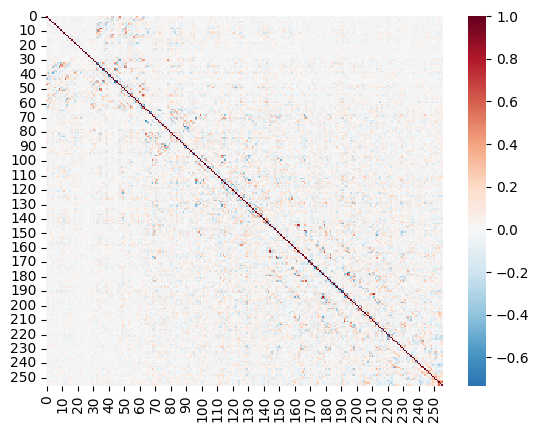

In [21]:
sns.heatmap(np.corrcoef(tl.to_numpy(Xt), rowvar=False),  cmap='RdBu_r', center=0)

In [22]:
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib import pyplot as plt

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(Xt_flat)
    df = pd.DataFrame(Xt_viz, columns=['PC1', 'PC2'])
    df['label'] = y
    df=df.reset_index()
    print(df)
    #sns.scatterplot(data=df, x='PC1', y='PC2', hue='label',)
    sns.kdeplot(data=df, x='PC1', y='PC2', hue='label',)
    ax = plt.gca()    
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

NameError: name 'Xt_flat' is not defined

In [ ]:
 import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

In [ ]:
from mne import EvokedArray
for b in bttda.blocks_[:8]:
    means_rec = b.inv_transform(b.transform(b.means_))
    contrast = means_rec[1]-means_rec[0]
    contrast = EvokedArray(tl.to_numpy(contrast), epochs.info, epochs.tmin)
    contrast.plot_joint(**joint_args)